In [42]:
#setup
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
beef_url = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/csv-export-2026-04-13.csv"
pollution_url = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/FAOSTAT_data_en_4-13-2026.csv"
beef = pd.read_csv(beef_url)
pollution = pd.read_csv(pollution_url)
#beef.head()
#pollution.head()

In [43]:
import matplotlib.pyplot as plt

In [44]:
#beef
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

beef['BeefPrice'] = beef[months].mean(axis=1)

beef = beef[['Year', 'BeefPrice']]

beef.head()

,Year,BeefPrice
0,1984,1.287167
1,1985,1.237500
2,1986,1.232000
3,1987,1.309917
4,1988,1.364750


In [45]:
#pollute
pollution = pollution[['Year', 'Value']]

pollution = pollution.rename(columns={'Value': 'Emissions'})

pollution.head()

,Year,Emissions
0,1961,6876.7867
1,1962,6980.1400
2,1963,7136.3680
3,1964,7251.5884
4,1965,7253.3471


In [46]:
#combining beef and pollution
merged = pd.merge(beef, pollution, on='Year', how='inner')

merged.head()

,Year,BeefPrice,Emissions
0,1984,1.287167,7094.6320
1,1985,1.237500,6899.2465
2,1986,1.232000,6654.7280
3,1987,1.309917,6446.5550
4,1988,1.364750,6316.8100


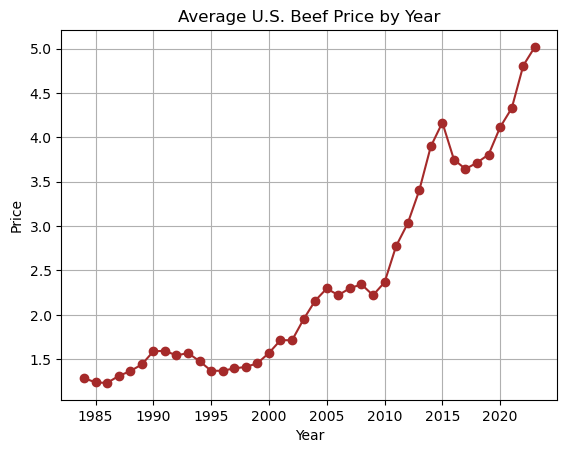

In [47]:
#beef plot
plt.figure()
plt.plot(merged['Year'], merged['BeefPrice'], marker='o', color = 'brown')
plt.title('Average U.S. Beef Price by Year')
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid()
plt.show()


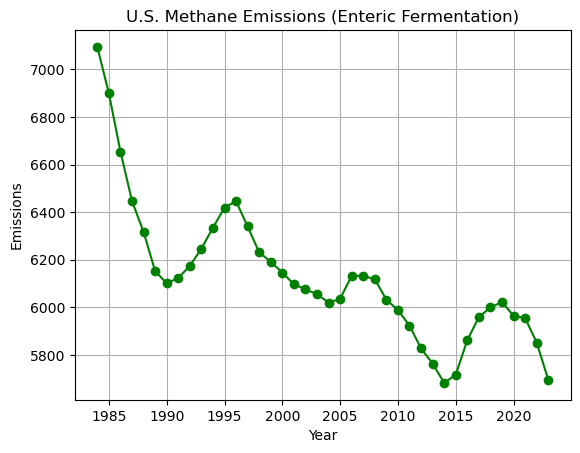

In [48]:
#pollution plot
plt.figure()
plt.plot(merged['Year'], merged['Emissions'], marker='o', color = 'green')
plt.title('U.S. Methane Emissions (Enteric Fermentation)')
plt.xlabel('Year')
plt.ylabel('Emissions')
plt.grid()
plt.show()

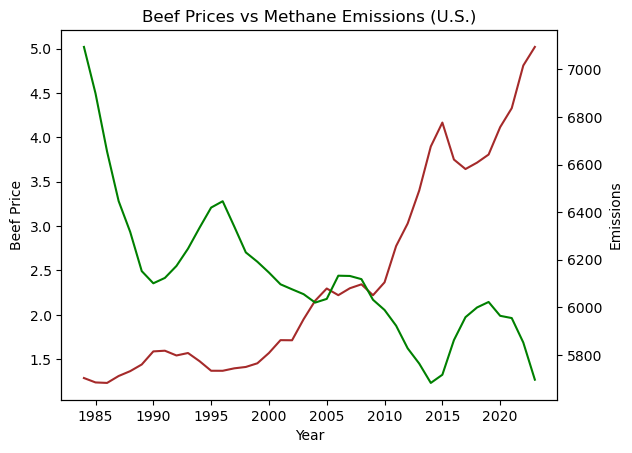

In [49]:
#merged line graph
fig, ax1 = plt.subplots()

ax1.plot(merged['Year'], merged['BeefPrice'], color = 'brown')
ax1.set_xlabel('Year')
ax1.set_ylabel('Beef Price')

ax2 = ax1.twinx()
ax2.plot(merged['Year'], merged['Emissions'], color = 'green')
ax2.set_ylabel('Emissions')

plt.title('Beef Prices vs Methane Emissions (U.S.)')
plt.show()

In [50]:
# r and p
r, p = pearsonr(merged['BeefPrice'], merged['Emissions'])

print("r:", r)
print("p-value:", p)

r: -0.7341412168115732
p-value: 7.00691782285512e-08


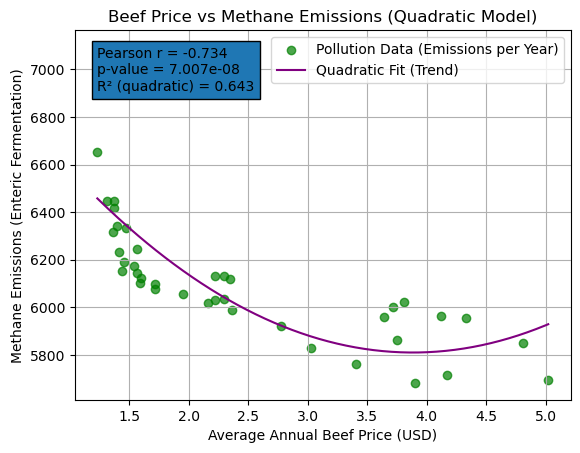

In [53]:
#final fancy merged
x = merged['BeefPrice']
y = merged['Emissions']

r, p = pearsonr(x, y)

coeffs = np.polyfit(x, y, 2)
poly = np.poly1d(coeffs)

x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = poly(x_smooth)

y_pred = poly(x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot)

plt.figure()

plt.scatter(x, y, color='green', alpha=0.7,
            label='Pollution Data (Emissions per Year)')

plt.plot(x_smooth, y_smooth, color='purple',
         label='Quadratic Fit (Trend)')

plt.xlabel('Average Annual Beef Price (USD)')
plt.ylabel('Methane Emissions (Enteric Fermentation)')
plt.title('Beef Price vs Methane Emissions (Quadratic Model)')

plt.legend()

plt.text(
    x.min(),
    y.max(),
    f'Pearson r = {r:.3f}\np-value = {p:.3e}\nR² (quadratic) = {r2:.3f}',
    verticalalignment='top',
    bbox=dict()
)

# Grid
plt.grid()

plt.show()